              STEADY-STATE ANALYSIS REPORT
Total Simulated Time     : 300 minutes
Identified Warm-up Period: 50 minutes (Data truncated)
------------------------------------------------------------
Overall Mean (With Warm-up) : 7.4636 min
Steady-State Mean (Correct) : 6.9991 min


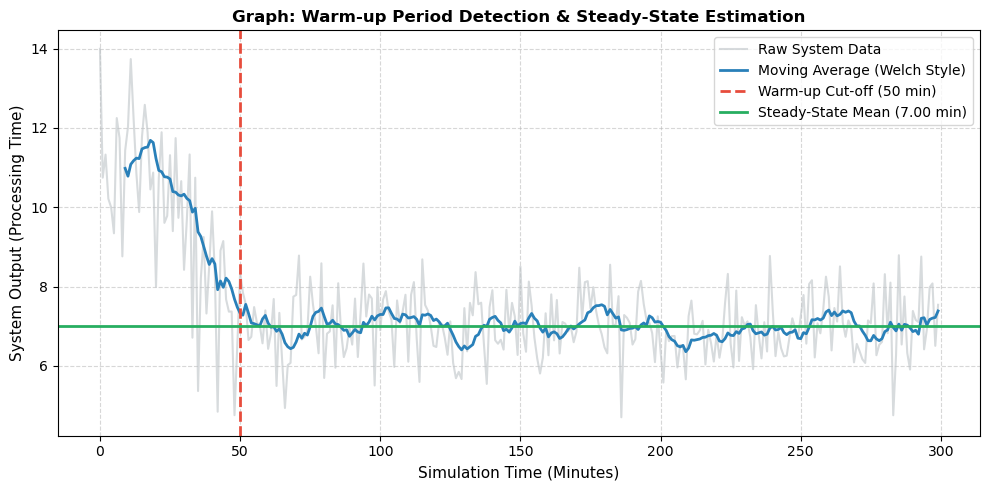

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- ১. প্যারামিটার ও বাস্তবসম্মত ডেটা জেনারেট করা ---
np.random.seed(24)
total_time = 300 # ৩০০ মিনিটের সিমুলেশন
warm_up_actual = 50 # প্রথম ৫০ মিনিট হলো ওয়ার্ম আপ

# ডেটা তৈরি: শুরুর দিকে সিস্টেম স্লো থাকবে (Transient), পরে স্টেডি হবে
production_times = []
for t in range(total_time):
    if t < warm_up_actual:
        # শুরুর দিকে ফ্যাক্টরি খালি, তাই প্রসেসিং টাইম বেশি ও অস্থির লাগবে
        val = np.random.normal(loc=12.0 - (t * 0.1), scale=1.5)
    else:
        # ৫০ মিনিট পর সিস্টেম স্টেডি স্টেটে চলে আসবে (গড় প্রায় ৭.০ মিনিট)
        val = np.random.normal(loc=7.0, scale=0.8)
    production_times.append(max(2.0, val))

# --- ২. মুভিং অ্যাভারেজ এবং স্টেডি-স্টেট মিন ক্যালকুলেশন ---
window = 10
moving_avg = np.convolve(production_times, np.ones(window)/window, mode='valid')

# প্রথম ৫০ মিনিটের ওয়ার্ম-আপ ডাটা বাদ দিয়ে আসল স্টেডি স্টেট মিন বের করা
steady_state_data = production_times[warm_up_actual:]
steady_mean = np.mean(steady_state_data)

# --- ৩. টেক্সট রিপোর্ট প্রিন্ট ---
print("=" * 60)
print("              STEADY-STATE ANALYSIS REPORT")
print("=" * 60)
print(f"Total Simulated Time     : {total_time} minutes")
print(f"Identified Warm-up Period: {warm_up_actual} minutes (Data truncated)")
print("-" * 60)
print(f"Overall Mean (With Warm-up) : {np.mean(production_times):.4f} min")
print(f"Steady-State Mean (Correct) : {steady_mean:.4f} min")
print("=" * 60)

# --- ৪. গ্রাফ প্রদর্শন (Steady-State Plot) ---
plt.figure(figsize=(10, 5))
plt.plot(production_times, color='#bdc3c7', alpha=0.6, label='Raw System Data')
plt.plot(range(window-1, total_time), moving_avg, color='#2980b9', linewidth=2, label='Moving Average (Welch Style)')

# ওয়ার্ম-আপ পিরিয়ডের জন্য লাল দাগ
plt.axvline(x=warm_up_actual, color='#e74c3c', linestyle='--', linewidth=2, label=f'Warm-up Cut-off ({warm_up_actual} min)')
# স্টেডি স্টেট মিনের জন্য সবুজ সোজা লাইন
plt.axhline(y=steady_mean, color='#27ae60', linestyle='-', linewidth=2, label=f'Steady-State Mean ({steady_mean:.2f} min)')

plt.title("Graph: Warm-up Period Detection & Steady-State Estimation", fontsize=12, fontweight='bold')
plt.xlabel("Simulation Time (Minutes)", fontsize=11)
plt.ylabel("System Output (Processing Time)", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()